In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data/Online Retail.csv", encoding="latin-1")

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
df.shape

(541909, 8)

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(5268)

In [15]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [21]:
df = df.drop_duplicates()

In [22]:
df.shape

(535187, 8)

In [25]:
df = df.dropna(subset=["Description"])
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64

In [27]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [28]:
df["Quantity"].min()

np.int64(-80995)

In [30]:
df = df[df["Quantity"] > 0]
df["Quantity"].min()

np.int64(1)

In [31]:
df["UnitPrice"].min()

np.float64(-11062.06)

In [33]:
df = df[df["UnitPrice"] > 0]
df["UnitPrice"].min()

np.float64(0.001)

In [34]:
df.shape

(524878, 8)

In [35]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [37]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [38]:
df["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [39]:
df["Revenue"].sum()

np.float64(10642110.804000001)

In [41]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [42]:
top_10_products = top_products.head(10).sort_values()

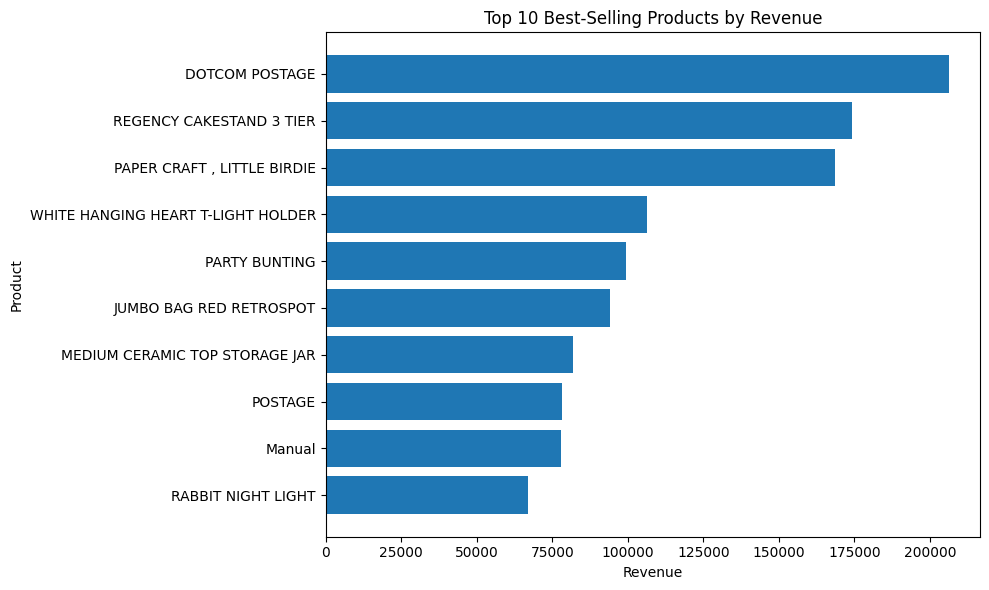

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products.index,
    top_10_products.values
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Best-Selling Products by Revenue")

plt.tight_layout()

plt.savefig(
    "visuals/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
top_products.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [47]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [48]:
top_10_countries = country_revenue.head(10).sort_values()

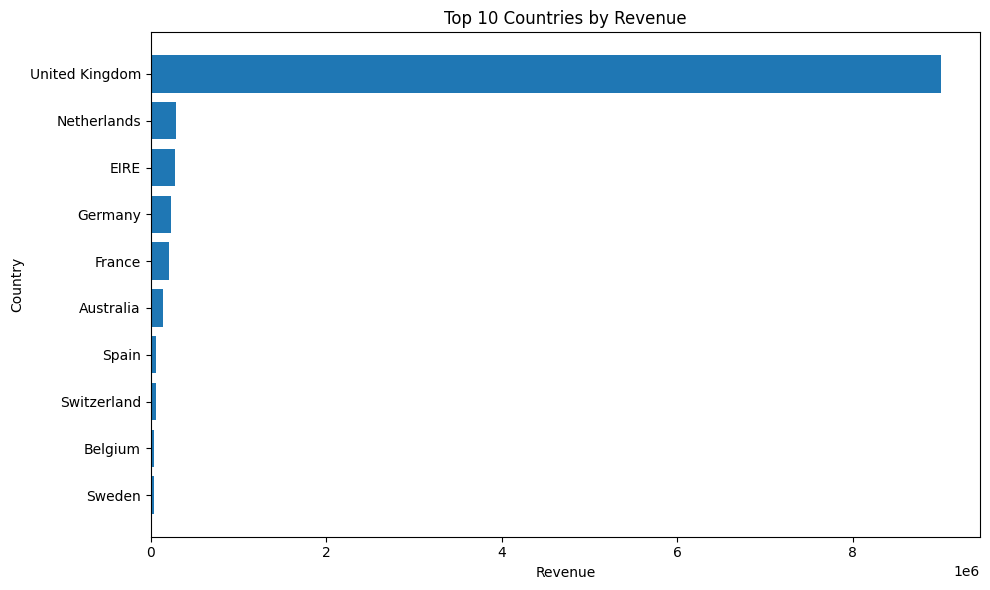

In [49]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries.index,
    top_10_countries.values
)

plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")

plt.tight_layout()

plt.savefig(
    "visuals/top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [50]:
country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [52]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

In [53]:
monthly_revenue.index = monthly_revenue.index.to_timestamp()

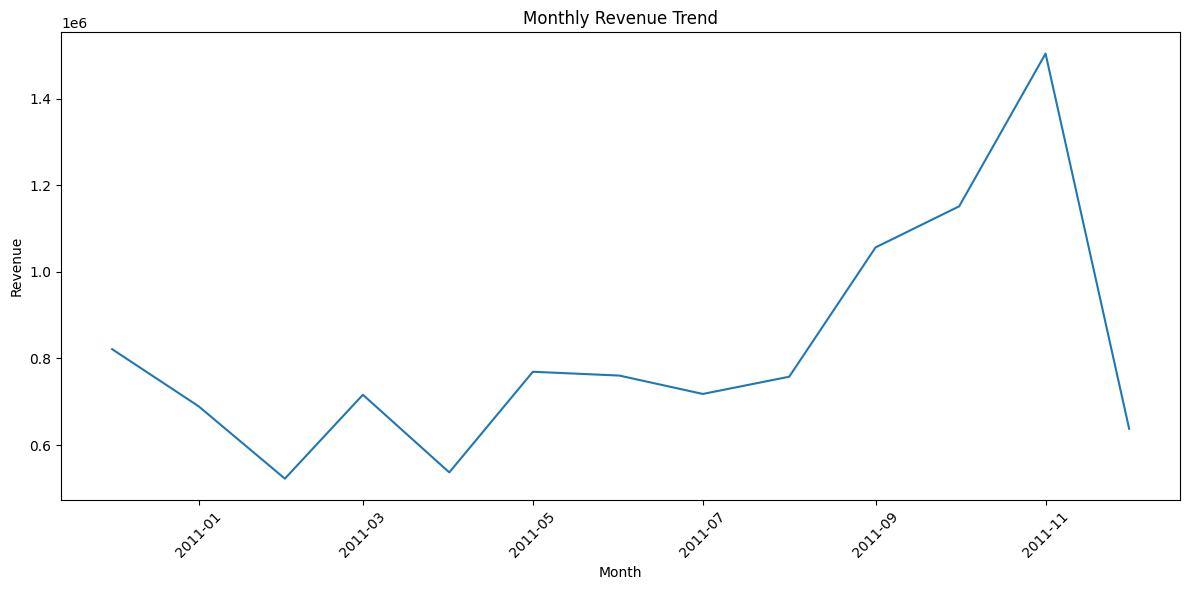

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "visuals/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
monthly_growth = monthly_revenue.pct_change() * 100
monthly_growth

Month
2010-12-01          NaN
2011-01-01   -16.025404
2011-02-01   -24.248077
2011-03-01    37.062740
2011-04-01   -25.026941
2011-05-01    43.266620
2011-06-01    -1.137351
2011-07-01    -5.584256
2011-08-01     5.537750
2011-09-01    39.400568
2011-10-01     8.976276
2011-11-01    30.627478
2011-12-01   -57.589972
Freq: MS, Name: Revenue, dtype: float64

In [58]:
monthly_growth.round(2)

Month
2010-12-01      NaN
2011-01-01   -16.03
2011-02-01   -24.25
2011-03-01    37.06
2011-04-01   -25.03
2011-05-01    43.27
2011-06-01    -1.14
2011-07-01    -5.58
2011-08-01     5.54
2011-09-01    39.40
2011-10-01     8.98
2011-11-01    30.63
2011-12-01   -57.59
Freq: MS, Name: Revenue, dtype: float64

In [59]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [60]:
monthly_growth.idxmax(), monthly_growth.max()

(Timestamp('2011-05-01 00:00:00'), np.float64(43.2666204617209))

In [61]:
monthly_growth.idxmin(), monthly_growth.min()

(Timestamp('2011-12-01 00:00:00'), np.float64(-57.58997150000216))

In [62]:
total_revenue = df["Revenue"].sum()

total_revenue

np.float64(10642110.804000001)

In [63]:
total_orders = df["InvoiceNo"].nunique()

total_orders

19960

In [64]:
top_product = top_products.index[0]

top_product

'DOTCOM POSTAGE'

In [65]:
top_country = country_revenue.index[0]

top_country

'United Kingdom'

In [66]:
latest_month_growth = monthly_growth.iloc[-1]

latest_month_growth

np.float64(-57.58997150000216)

In [67]:
kpi_summary = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Top Product": top_product,
    "Top Country": top_country,
    "Latest Monthly Growth": latest_month_growth
}

kpi_summary

{'Total Revenue': np.float64(10642110.804000001),
 'Total Orders': 19960,
 'Top Product': 'DOTCOM POSTAGE',
 'Top Country': 'United Kingdom',
 'Latest Monthly Growth': np.float64(-57.58997150000216)}

In [69]:
df[
    df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
]["Description"].value_counts()

Description
POSTAGE           1126
DOTCOM POSTAGE     706
Manual             317
Name: count, dtype: int64

In [71]:
merchandise_df = df[
    ~df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
].copy()

merchandise_products = (
    merchandise_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [73]:
df[
    df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
]["Description"].value_counts()

Description
POSTAGE           1126
DOTCOM POSTAGE     706
Manual             317
Name: count, dtype: int64

In [72]:
merchandise_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

In [75]:
top_10_merchandise = merchandise_products.head(10).sort_values()

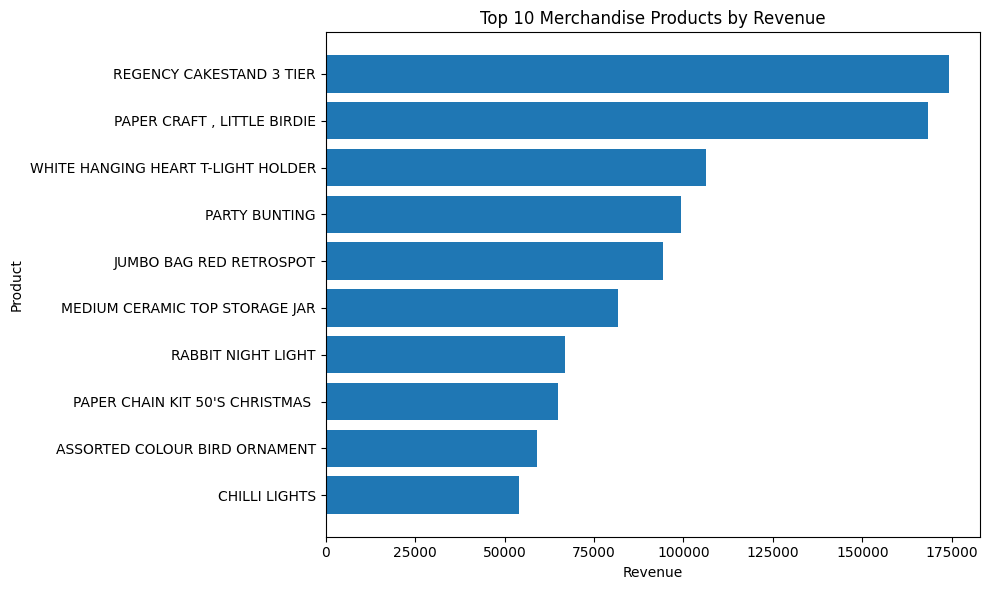

In [76]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_merchandise.index,
    top_10_merchandise.values
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Merchandise Products by Revenue")

plt.tight_layout()

plt.savefig(
    "visuals/top_10_merchandise_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
top_10_merchandise_df = (
    merchandise_products
    .head(10)
    .to_frame(name="Revenue")
)

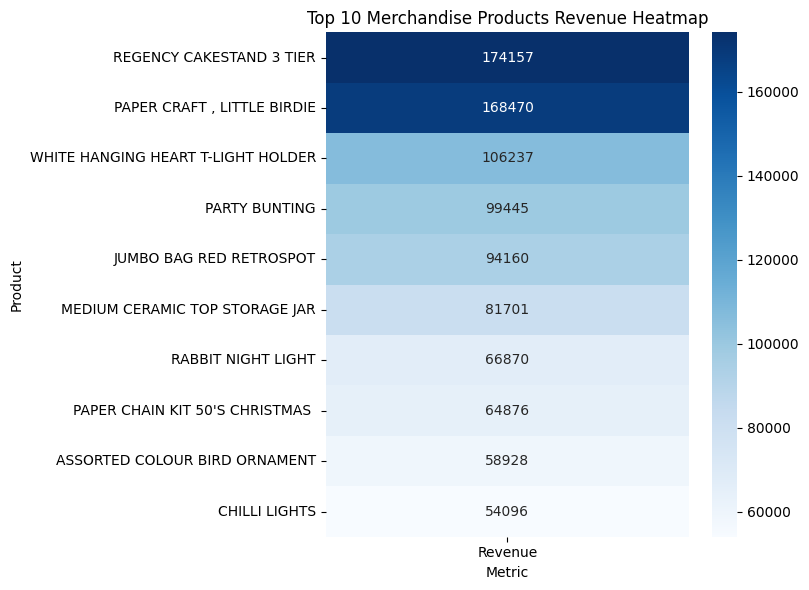

In [78]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    top_10_merchandise_df,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Top 10 Merchandise Products Revenue Heatmap")
plt.xlabel("Metric")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "visuals/product_revenue_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
top_quantity_products = (
    merchandise_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
top_quantity_products.head(10)


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

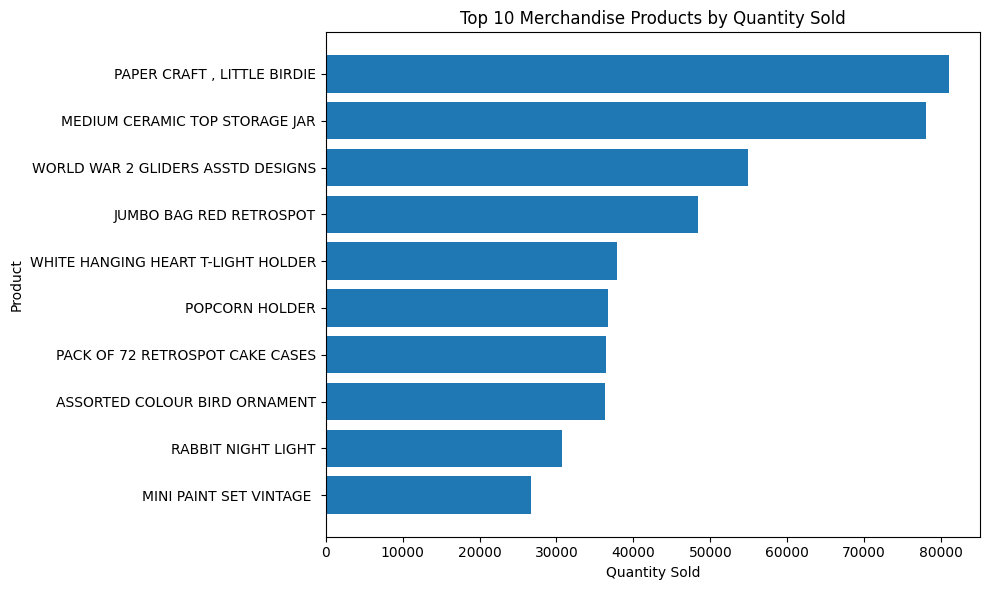

In [84]:
top_10_quantity = top_quantity_products.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_quantity.index,
    top_10_quantity.values
)

plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Merchandise Products by Quantity Sold")

plt.tight_layout()

plt.savefig(
    "visuals/top_10_quantity_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
total_quantity = merchandise_df["Quantity"].sum()

total_quantity

np.int64(5561579)

In [85]:
unique_products = merchandise_df["Description"].nunique()

unique_products

4023

In [87]:
unique_countries = df["Country"].nunique()

unique_countries

38

## Key Insights

1. The cleaned dataset contains 524,878 transaction records.

2. Total revenue generated from the cleaned transactions is approximately 10.64 million.

3. The dataset contains 19,960 unique orders.

4. The United Kingdom is the top revenue-generating country, with revenue of approximately 9.00 million.

5. REGENCY CAKESTAND 3 TIER is the highest-revenue merchandise product, generating approximately 174,156.54.

6. PAPER CRAFT , LITTLE BIRDIE is the highest-quantity merchandise product, with 80,995 units sold.

7. PAPER CRAFT , LITTLE BIRDIE is also one of the highest-revenue merchandise products, generating approximately 168,469.60.

8. November 2011 recorded the highest monthly revenue at approximately 1.50 million.

9. May 2011 recorded the highest month-to-month revenue growth at approximately 43.27%.

10. December 2011 shows a month-to-month decline of approximately 57.59%, but the dataset only contains data through December 9, so this should not be interpreted as a complete-month decline.

11. The dataset contains 4,023 unique merchandise products across 38 countries.

12. The dataset does not contain a separate category or product-line column, so product-level and country-level performance were analyzed instead.

## Conclusion

This project analyzed e-commerce transaction data to understand revenue, product performance, sales quantity, country-wise performance, and monthly revenue trends.

The analysis included data cleaning, duplicate removal, missing-value handling, date conversion, removal of invalid quantities and prices, and revenue calculation using Quantity × UnitPrice.

The analysis identified the highest-performing merchandise products, the leading revenue-generating country, monthly revenue patterns, and month-to-month growth trends.

The results show that the United Kingdom contributed the largest share of revenue, while REGENCY CAKESTAND 3 TIER was the highest-revenue merchandise product. PAPER CRAFT , LITTLE BIRDIE recorded the highest quantity sold.

The project demonstrates how Pandas, Matplotlib, and Seaborn can be used to transform raw e-commerce transaction data into useful business insights and dashboard-ready visualizations.